# 04. cuPF GPU path: cuDSS, Edge, EdgeAtomic, VertexWarp

GPU path에서는 두 병목을 옮깁니다.

- Jacobian fill: bus/branch sparse pattern에 맞춰 CUDA kernel이 값을 채웁니다.
- Sparse linear solve: cuDSS 또는 custom solver가 `J dx = F`를 풉니다.

현재 public option으로 `CudaJacobianKind.Edge`, `EdgeAtomic`, `VertexWarp`를 선택할 수 있습니다. 실험적으로는 edge/vertex 차이가 아주 크게 나지 않을 수 있습니다. 큰 비용은 여전히 sparse factorization/solve 쪽에 남기 쉽기 때문입니다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_LIVE = True


In [2]:
print('Building CPU and GPU evaluation artifacts...')
cpu_build = tu.build_eval('cpu', jobs=2, timeout=2400)
print(tu.command_summary(cpu_build))
gpu_build = tu.build_eval('gpu', jobs=2, timeout=3600)
print(tu.command_summary(gpu_build))


Building CPU and GPU evaluation artifacts...


$ bash benchmark/scripts/build_eval.bash cpu --jobs 2
[OK] elapsed=0.2s
[build_eval] configure (cpu) -> /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
-- spdlog not found: disabling cuPF logging
-- Found pybind11: /usr/local/include (found version "3.0.1")
-- Configuring done
-- Generating done
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target cupf
[ 87%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 82%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/_cupf.cp

$ bash benchmark/scripts/build_eval.bash gpu --jobs 2
[OK] elapsed=0.3s
[build_eval] configure (gpu) -> /workspace/gpu-powerflow-master/cuPF/build/eval-gpu
-- spdlog not found: disabling cuPF logging
-- cuDSS reordering algorithm: DEFAULT
-- cuDSS MT mode: OFF
-- cuDSS host threads: AUTO
-- cuDSS ND_NLEVELS: AUTO
-- Found pybind11: /usr/local/include (found version "3.0.1")
-- Configuring done
-- Generating done
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-gpu
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target cupf
[ 89%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 86%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-gpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF

$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-gpu-20260601-103942 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-cpu-klu-pybind cupf-fp64-cudss-pybind cupf-fp64-cudss-edge-atomic-pybind cupf-fp64-cudss-vertex-warp-pybind
[OK] elapsed=14.3s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-gpu-20260601-103942 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-cpu-klu-pybind cupf-fp64-cudss-edge-atomic-pybind cupf-fp64-cudss-pybind cupf-fp64-cudss-vertex-warp-pybind
[cupf-cpu-klu-pybind][OK] case6468rte repeat=0 init_ms=7.788 solve_ms=12.212 iters=4 resid=1.341e-11
[cupf-cpu-klu-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/

,variant,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual
0,cupf-cpu-klu-pybind,klu,native,7.788233,12.212122,1.340572e-11
2,cupf-fp64-cudss-pybind,cudss,edge,83.854943,21.469789,1.832079e-11
1,cupf-fp64-cudss-edge-atomic-pybind,cudss,edge_atomic,83.796713,22.090372,1.033997e-11
3,cupf-fp64-cudss-vertex-warp-pybind,cudss,vertex_warp,84.043355,22.221598,7.514797e-12


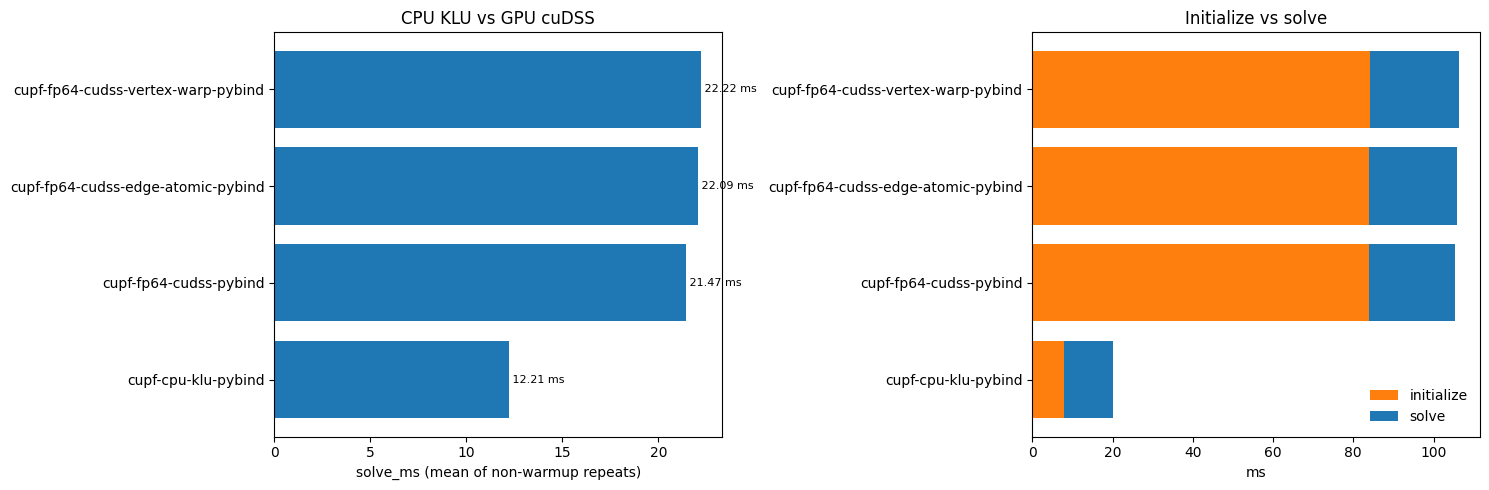

In [3]:
variants = [
    'cupf-cpu-klu-pybind',
    'cupf-fp64-cudss-pybind',
    'cupf-fp64-cudss-edge-atomic-pybind',
    'cupf-fp64-cudss-vertex-warp-pybind',
]
if RUN_LIVE:
    run_dir, result = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-gpu'),
        cases=[TUTORIAL_CASE],
        repeats=1,
        warmup=0,
        timeout=3600,
    )
    print(tu.command_summary(result))
else:
    run_dir = tu.tutorial_output_root()

print(f"run_dir={run_dir}")
runs = tu.load_tutorial_runs(run_dir)
summary = tu.summarize_runs(runs)
display(summary[['variant', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual']])
skipped = tu.skipped_variants(run_dir)
if not skipped.empty:
    display(skipped)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
tu.plot_run_solve_bars(summary, axes[0], 'CPU KLU vs GPU cuDSS')
tu.plot_init_solve_stack(summary, axes[1], 'Initialize vs solve')
plt.tight_layout()


## Optional custom solver build

custom solver는 연구용 경로입니다. 빌드나 런타임 지원이 없으면 실패가 아니라 skip/diagnostic으로 처리합니다.


In [4]:
custom_build = tu.build_eval('gpu-custom', jobs=2, timeout=3600)
print(tu.command_summary(custom_build))
if custom_build.ok:
    custom_dir, custom_result = tu.run_tutorial_benchmark(
        variants=['cupf-fp64-custom-pybind'],
        run_name=tu.timestamp_run_name('tutorial-gpu-custom'),
        cases=[TUTORIAL_CASE],
        repeats=1,
        warmup=0,
        timeout=3600,
    )
    print(tu.command_summary(custom_result))
    display(tu.summarize_runs(tu.load_tutorial_runs(custom_dir)))
    skipped = tu.skipped_variants(custom_dir)
    if not skipped.empty:
        display(skipped)
else:
    print('custom solver live run skipped because gpu-custom build did not complete.')


$ bash benchmark/scripts/build_eval.bash gpu-custom --jobs 2
[OK] elapsed=3.2s
-- Configuring done
-- Generating done
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-gpu-custom
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target custom_linear_solver_ops
[ 25%] Built target custom_linear_solver_ops
Consolidate compiler generated dependencies of target cupf
[ 28%] Building CXX object CMakeFiles/cupf.dir/cpp/src/newton_solver/core/newton_solver.cpp.o
[ 30%] Linking CXX static library libcupf.a
[ 92%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[ 94%] Linking CUDA device code CMakeFiles/_cupf.dir/cmake_device_link.o
[ 97%] Linking CXX shared module _cupf.cpython-310-x86_64-linux-gnu.so
[100%] Built target _cupf
[ 25%] Built target custom_linear_solver_ops
Consolidate compiler generated dependencies of target cupf
[ 90%] Built target cupf
Consolidate compiler generate

$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-gpu-custom-20260601-103959 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-fp64-custom-pybind
[OK] elapsed=4.3s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-gpu-custom-20260601-103959 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-fp64-custom-pybind
[cupf-fp64-custom-pybind][OK] case6468rte repeat=0 init_ms=19.525 solve_ms=181.660 iters=4 resid=8.643e-12
[cupf-fp64-custom-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-gpu-custom-20260601-103959/cupf-fp64-custom-pybind/runs.csv
[aggregate] 1 rows -> /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-g

,variant,cases,successful_rows,converged_rows,initialize_ms,solve_ms,worst_residual,linear_solver,jacobian,entrypoint
0,cupf-fp64-custom-pybind,1,1,1,19.524534,181.659736,8.642712e-12,custom,edge,pybind


Edge는 nonzero/branch 중심으로 병렬성을 크게 확보합니다. EdgeAtomic은 diagonal fan-in을 atomic add로 처리하는 legacy 비교 경로입니다. VertexWarp는 bus/row 중심으로 한 warp가 한 bus 주변 항을 모으는 방식이라 load imbalance가 생길 수 있지만 atomic 비용은 줄일 수 있습니다. 실제 효과는 case topology와 선형 solver 비용 비중에 따라 달라집니다.
